# Predicción con Arboles de Decisión / Random Forest

In [2]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

## Importar los datos

In [4]:
data = pd.read_csv("final_data.csv")
data.head()

,Unnamed: 0,order_id,media_review_score,fecha_ultima_review,order_purchase_timestamp,delivered_status,delay_time,customer_unique_id,customer_state,number_payments,...,product_id,seller_id,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_state
0,0,00010242fe8c5a6d1ba2dd792cb16214,5,2017-09-21,2017-09-13,1,9,871766c5855e863f6eccc05f988b23cb,Southeast,1.0,...,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,598.0,4.0,650.0,28.0,9.0,14.0,Miscellaneous and Other Items,Southeast
1,1,00018f77f2f0320c557190d7a144bdd3,4,2017-05-13,2017-04-26,1,3,eb28e67c4c0b83846050ddfb8a35d051,Southeast,1.0,...,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.0,2.0,30000.0,50.0,30.0,40.0,Miscellaneous and Other Items,Southeast
2,2,000229ec398224ef6ca0657da4fc703e,5,2018-01-23,2018-01-14,1,14,3818d81c6709e39d06b2738a8d3a2474,Southeast,1.0,...,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,695.0,2.0,3050.0,33.0,13.0,33.0,Home and Decoration,Southeast
3,3,00024acbcdf0a6daa1e931b038114c75,4,2018-08-15,2018-08-08,1,6,af861d436cfc08b2c2ddefd0ba074622,Southeast,1.0,...,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,480.0,1.0,200.0,16.0,10.0,15.0,Fashion and Personal Care,Southeast
4,4,00042b26cf59d7ce69dfabb4e55b4fd9,5,2017-03-02,2017-02-04,1,16,64b576fb70d441e8f1b2d7d446e483c5,Southeast,1.0,...,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,409.0,1.0,3750.0,35.0,40.0,30.0,Tools and Construction,South


In [5]:
# dropeo columna Unnamed
data = data.drop(columns = data.columns[0])

In [6]:
data.shape

(97916, 25)

In [7]:
data.nunique()

order_id                         97916
media_review_score                   5
fecha_ultima_review                632
order_purchase_timestamp           615
delivered_status                     2
delay_time                         197
customer_unique_id               94720
customer_state                       6
number_payments                     20
payment_value_sum                27474
payment_type                         5
number_items                        17
total_price                       7587
total_freight_value               7666
total_diff_items                     8
product_id                       30802
seller_id                         3066
product_description_lenght        2952
product_photos_qty                  19
product_weight_g                  2188
product_length_cm                   99
product_height_cm                  102
product_width_cm                    95
product_category_name_english        6
seller_state                         7
dtype: int64

In [8]:
data.dtypes

order_id                          object
media_review_score                 int64
fecha_ultima_review               object
order_purchase_timestamp          object
delivered_status                   int64
delay_time                         int64
customer_unique_id                object
customer_state                    object
number_payments                  float64
payment_value_sum                float64
payment_type                      object
number_items                     float64
total_price                      float64
total_freight_value              float64
total_diff_items                 float64
product_id                        object
seller_id                         object
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
product_category_name_english     object
seller_state    

In [9]:
type(data.loc[0, "fecha_ultima_review"])

str

In [10]:
# convertir fechas
data["fecha_ultima_review"] = pd.to_datetime(data["fecha_ultima_review"]).dt.normalize()
data["order_purchase_timestamp"] = pd.to_datetime(data["order_purchase_timestamp"]).dt.normalize()

In [11]:
type(data.loc[0, "fecha_ultima_review"])

pandas._libs.tslibs.timestamps.Timestamp

In [12]:
for i in data.columns:
    if data[i].nunique() < 50:
        print(f"{i}: {data[i].unique()}, {data[i].dtypes}")

media_review_score: [5 4 1 3 2], int64
delivered_status: [1 0], int64
customer_state: ['Southeast' 'South' 'West' 'Northeast' 'Central-West' 'North'], object
number_payments: [ 1.  2.  6.  3.  7.  4.  5. 11.  9. 12. 10. 15.  8. 22. 14. 13. 21. 26.
 19. 29.], float64
payment_type: ['credit_card' 'boleto' 'multiple_payments' 'debit_card' 'voucher'], object
number_items: [ 1.  2.  3.  4.  5.  6.  8.  7. 20. 12. 10. 13. 15. 11. 14. 21.  9.], float64
total_diff_items: [1. 2. 4. 3. 5. 6. 7. 8.], float64
product_photos_qty: [ 4.  2.  1.  3.  5.  8.  7.  9.  6. 10. 13. 11. 15. 12. 18. 20. 17. 19.
 14.], float64
product_category_name_english: ['Miscellaneous and Other Items' 'Home and Decoration'
 'Fashion and Personal Care' 'Tools and Construction'
 'Electronics and Technology' 'Leisure, Toys and Arts'], object
seller_state: ['Southeast' 'South' 'Central-West' 'unknown' 'West' 'Northeast' 'North'], object


## Análisis exploratoria

### Agregar variables calculadas a partir de id

#### Seller_id

In [16]:
ventas_por_vendedor = (
    data.loc[data['seller_id'] != 'multiple'].groupby('seller_id')['total_price']
    .sum()
    .sort_values(ascending=False)
)
ventas_acumuladas = ventas_por_vendedor.cumsum()
porcentaje_acumulado = ventas_acumuladas / ventas_por_vendedor.sum()
#Menos del 20% de vendedores explican el 80% de las ventas
num_vendedores_80 = (porcentaje_acumulado <= 0.80).sum()
num_vendedores_80
topN_vendedores = ventas_por_vendedor.head(num_vendedores_80).index
data['seller_topN'] = data['seller_id'].isin(topN_vendedores).astype(int)

<Axes: xlabel='seller_topN', ylabel='count'>

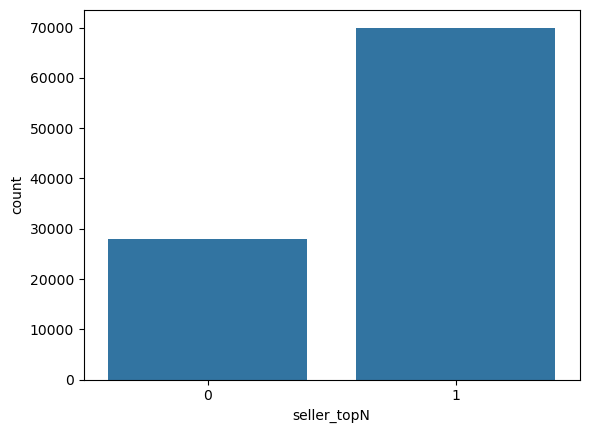

In [17]:
sns.countplot(
    data = data,
    x = "seller_topN"
)

In [18]:
data = data.drop(columns = "seller_id")

#### Product_id

In [20]:
ventas_por_producto = (
    data.loc[data['product_id'] != 'multiple'].groupby('product_id')['total_price']
    .sum()
    .sort_values(ascending=False)
)
ventas_acumuladas_prod = ventas_por_producto.cumsum()
porcentaje_acumulado_prod = ventas_acumuladas_prod / ventas_por_producto.sum()
#Menos del 30% de productos explican el 80% de las ventas
num_productos_80 = (porcentaje_acumulado_prod <= 0.80).sum()
num_productos_80
topN_productos = ventas_por_producto.head(num_productos_80).index
data['product_topN'] = data['product_id'].isin(topN_productos).astype(int)

<Axes: xlabel='product_topN', ylabel='count'>

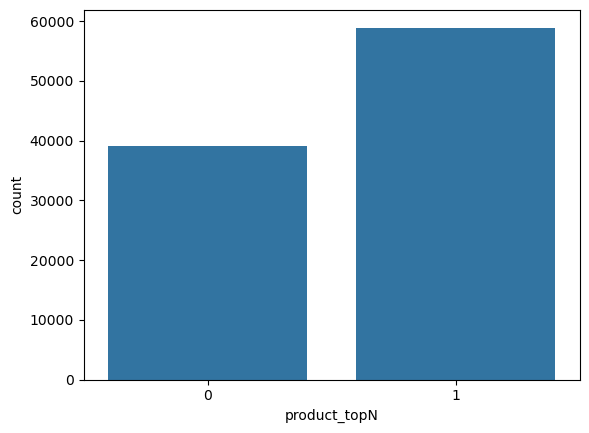

In [21]:
sns.countplot(
    data = data,
    x = "product_topN"
)

In [22]:
data = data.drop(columns = "product_id")

#### Customer_id

In [24]:
# agregar variable para saber si la compra se ha efectuado por un cliente que ya habia comprado
data = data.assign(
    repeat_customer = data.duplicated(subset = "customer_unique_id", keep = "first").astype(int)
)

In [25]:
data = data.drop(columns = "customer_unique_id")

### Distribución variables categóricas

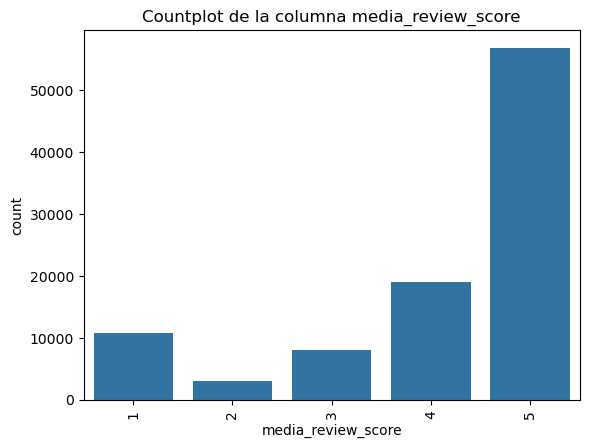

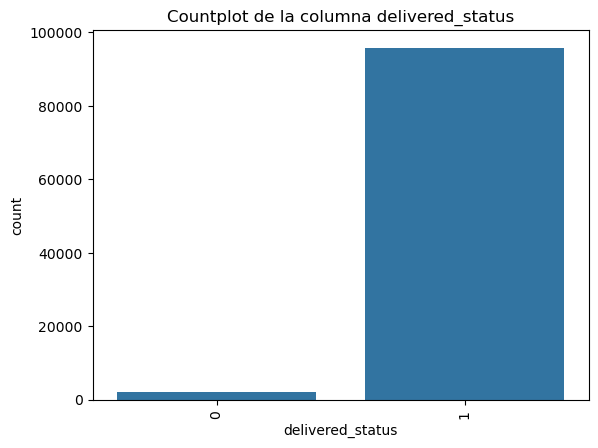

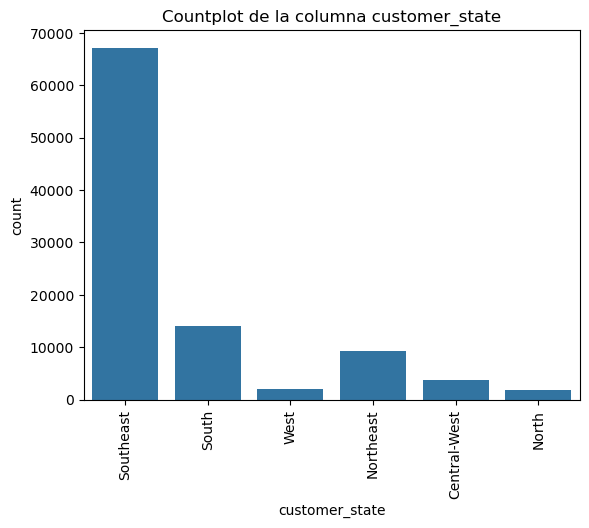

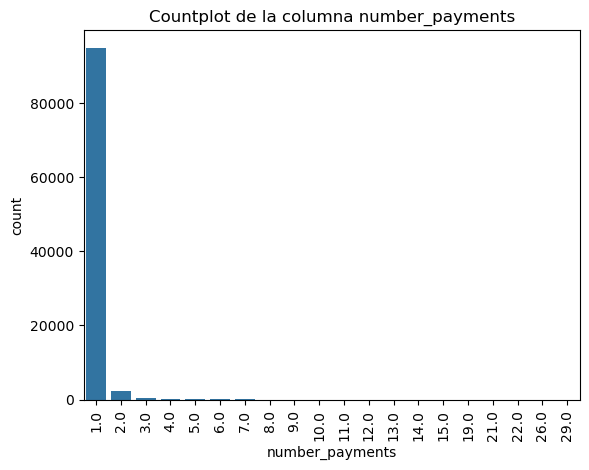

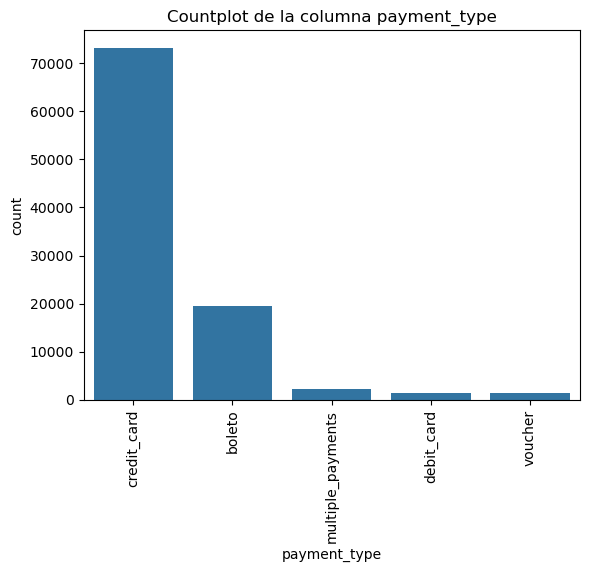

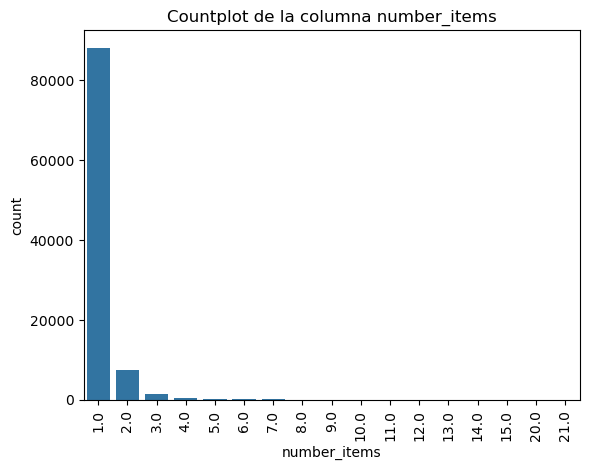

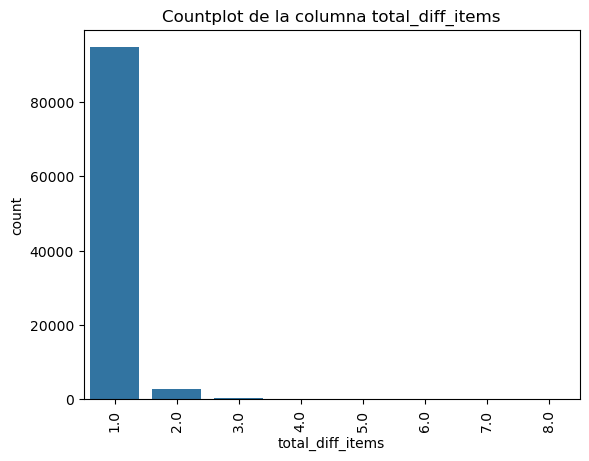

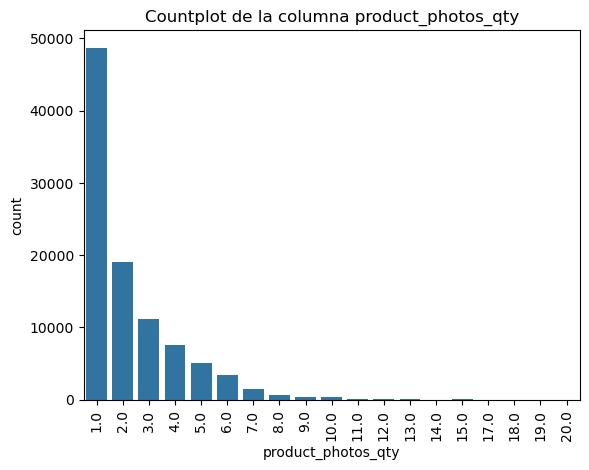

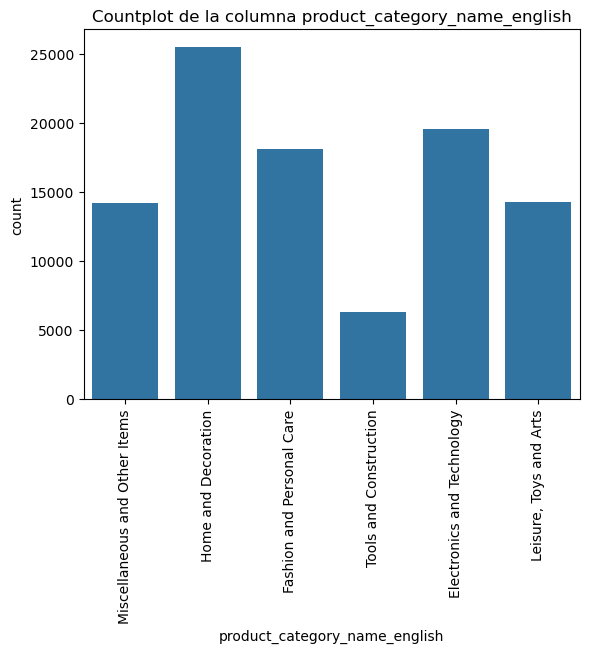

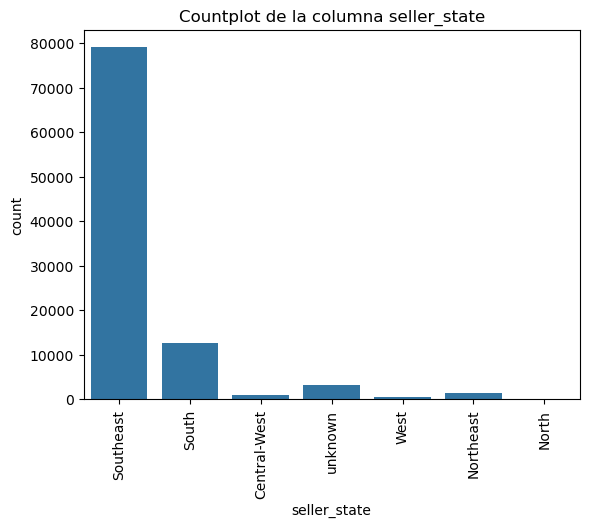

In [27]:
for columna in data[[
    "media_review_score", 
    "delivered_status",
    "customer_state",
    "number_payments",
    "payment_type",
    "number_items",
    "total_diff_items",
    "product_photos_qty",
    "product_category_name_english",
    "seller_state"
]]:
    sns.countplot(data = data, x = columna)
    plt.title(f"Countplot de la columna {columna}")
    plt.xticks(rotation = 90)
    plt.show() 

#### Review_score

In [29]:
# agrupar media_review_score en 3 grupos: (1,2) - (3,4) - (5)
data["media_review_score"] = data["media_review_score"].replace({
    1 : 0,
    2 : 0,
    3 : 0,
    4 : 0,
    5 : 1
})

<Axes: xlabel='media_review_score', ylabel='count'>

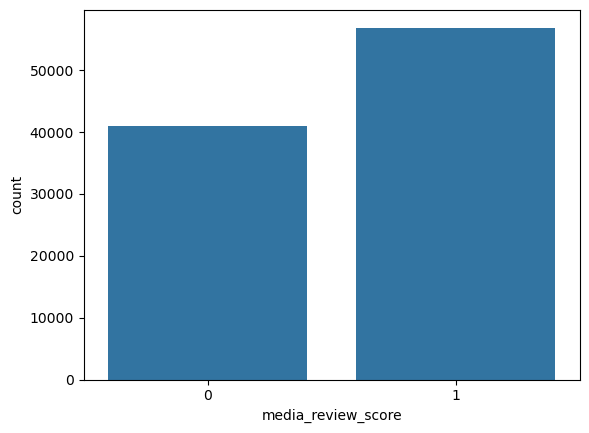

In [30]:
sns.countplot(
    data = data,
    x = "media_review_score"
)

#### Delivered_status

In [32]:
# estudiar distribución delivered_status
(data["delivered_status"].value_counts()/data["delivered_status"].size).cumsum()

delivered_status
1    0.978706
0    1.000000
Name: count, dtype: float64

In [33]:
# dropear columna de delivered_status porque muy polarizada (97.8% valores concentrados en un valor)
data = data.drop(columns = "delivered_status")

#### Customer_state

In [35]:
# estudiar distribución customer_state
(data["customer_state"].value_counts()/data["customer_state"].size).cumsum()

customer_state
Southeast       0.685996
South           0.828649
Northeast       0.923077
Central-West    0.961048
West            0.981413
North           1.000000
Name: count, dtype: float64

In [36]:
# agrupar customer_state en 4 grupos: Southeast, South, Northeast, Other
data["customer_state"] = data["customer_state"].replace({
    "Central-West" : "Other",
    "West" : "Other",
    "North" : "Other"
})

<Axes: xlabel='customer_state', ylabel='count'>

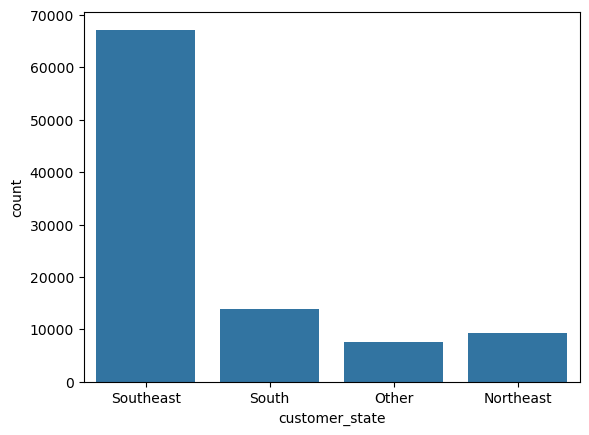

In [37]:
sns.countplot(
    data = data,
    x = "customer_state"
)

#### Number_payments

In [39]:
# estudiar distribución number_payments
(data["number_payments"].value_counts()/data["number_payments"].size).cumsum()

number_payments
1.0     0.970281
2.0     0.994199
3.0     0.997232
4.0     0.998315
5.0     0.998836
6.0     0.999193
7.0     0.999479
8.0     0.999581
11.0    0.999663
9.0     0.999745
12.0    0.999826
10.0    0.999867
13.0    0.999898
15.0    0.999918
14.0    0.999939
19.0    0.999959
22.0    0.999969
21.0    0.999980
26.0    0.999990
29.0    1.000000
Name: count, dtype: float64

<Axes: xlabel='number_payments', ylabel='count'>

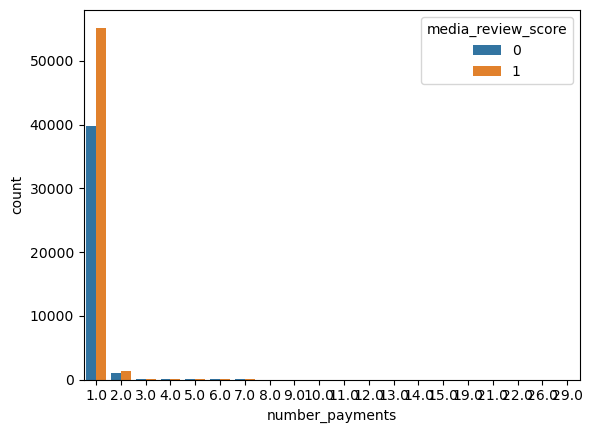

In [40]:
# estudiar distribución por review
sns.countplot(
    data = data,
    x = "number_payments",
    hue = "media_review_score"
)

In [41]:
# dropear columna number_payments porque muy polarizada (97% de los valores se concentran en 1 valor)
data = data.drop(columns = "number_payments")

#### Payment_type

In [43]:
# estudiar distribución payment_type
(data["payment_type"].value_counts()/data["payment_type"].size).cumsum()

payment_type
credit_card          0.747580
boleto               0.946434
multiple_payments    0.968984
voucher              0.984538
debit_card           1.000000
Name: count, dtype: float64

<Axes: xlabel='payment_type', ylabel='count'>

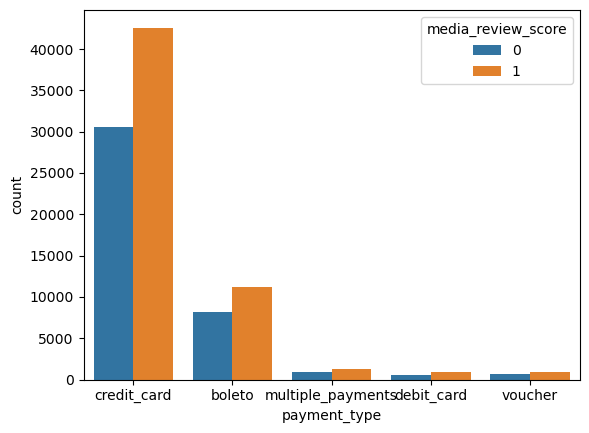

In [44]:
# estudiar distribución por review
sns.countplot(
    data = data,
    x = "payment_type",
    hue = "media_review_score"
)

In [45]:
# agrupar paymemt_type en 3 grupos: credit_card, boleto, other
data["payment_type"] = data["payment_type"].replace({
    "multiple_payments" : "Other",
    "voucher" : "Other",
    "debit_card" : "Other"
}) 

<Axes: xlabel='payment_type', ylabel='count'>

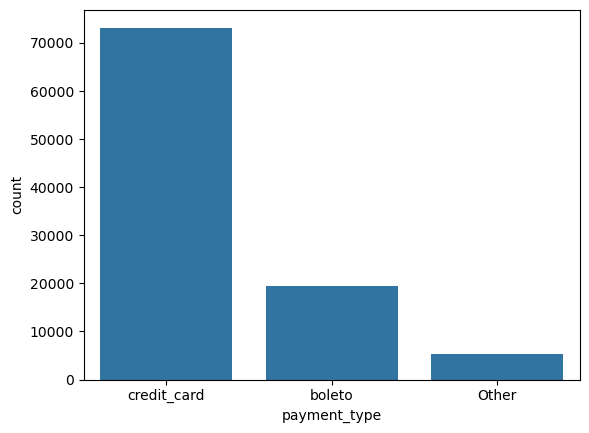

In [46]:
sns.countplot(
    data = data,
    x = "payment_type"
)

#### Number_items

In [48]:
# estudiar distribución number_items
(data["number_items"].value_counts()/data["number_items"].size).cumsum()

number_items
1.0     0.901048
2.0     0.977031
3.0     0.990298
4.0     0.995374
5.0     0.997457
6.0     0.999418
7.0     0.999643
8.0     0.999724
10.0    0.999806
12.0    0.999857
11.0    0.999898
9.0     0.999929
15.0    0.999949
14.0    0.999969
13.0    0.999980
21.0    0.999990
20.0    1.000000
Name: count, dtype: float64

<Axes: xlabel='number_items', ylabel='count'>

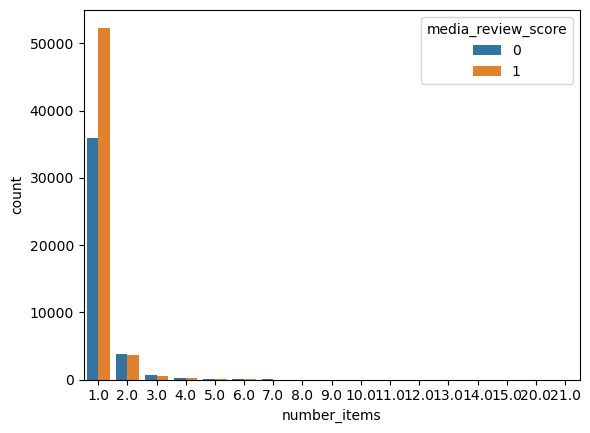

In [49]:
# estudiar distribución por review
sns.countplot(
    data = data,
    x = "number_items",
    hue = "media_review_score"
)

In [50]:
# agrupar number_items en 3 grupos: 1, 2, más de 2
data["number_items"] = np.where(
    data["number_items"] > 2,
    "Más de 2",
    data["number_items"]
)

<Axes: xlabel='number_items', ylabel='count'>

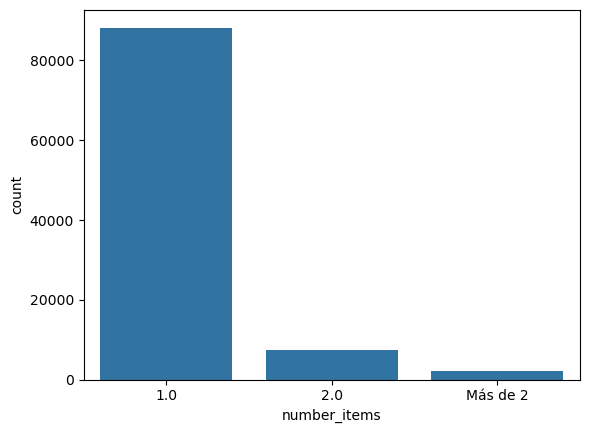

In [51]:
sns.countplot(
    data = data,
    x = "number_items"
)

#### Total_diff_items

In [53]:
# estudiar distribución
(data["total_diff_items"].value_counts()/data["total_diff_items"].size).cumsum()

total_diff_items
1.0    0.967350
2.0    0.996088
3.0    0.999081
4.0    0.999775
6.0    0.999877
5.0    0.999959
7.0    0.999990
8.0    1.000000
Name: count, dtype: float64

In [54]:
# dropear columna total_diff_items (96,7% valores concentrados en un valor)
data = data.drop(columns = "total_diff_items")

#### Product_photos_qty

In [56]:
# estudiar distribución
(data["product_photos_qty"].value_counts()/data["product_photos_qty"].size).cumsum()

product_photos_qty
1.0     0.497528
2.0     0.692563
3.0     0.806640
4.0     0.884197
5.0     0.935291
6.0     0.970311
7.0     0.984916
8.0     0.991973
10.0    0.995271
9.0     0.998243
11.0    0.998897
12.0    0.999387
13.0    0.999653
15.0    0.999775
17.0    0.999867
14.0    0.999929
18.0    0.999969
19.0    0.999990
20.0    1.000000
Name: count, dtype: float64

<Axes: xlabel='product_photos_qty', ylabel='count'>

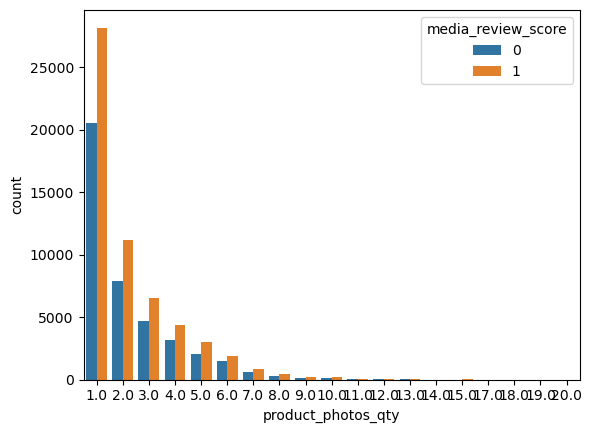

In [57]:
# estudiar distribución por review
sns.countplot(
    data = data,
    x = "product_photos_qty",
    hue = "media_review_score"
)

In [58]:
# agrupar product_photos_qty en 6 grupos: 1, 2, 3, 4, 5, >5
data["product_photos_qty"] = np.where(
    data["product_photos_qty"] > 5,
    "Más de 5",
    data["product_photos_qty"]
)

<Axes: xlabel='product_photos_qty', ylabel='count'>

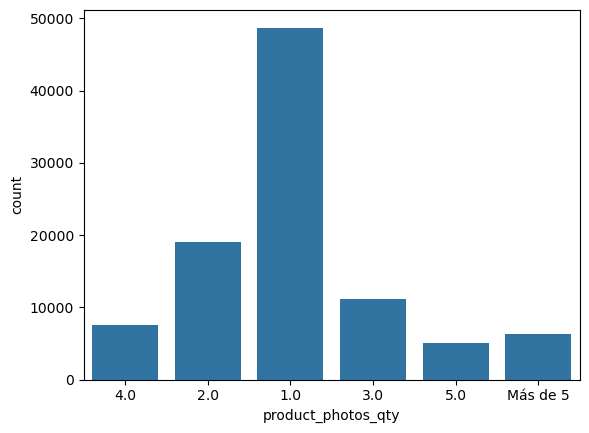

In [59]:
sns.countplot(
    data = data,
    x = "product_photos_qty"
)

#### Product_category

In [61]:
# estudiar distribución
(data["product_category_name_english"].value_counts()/data["product_category_name_english"].size).cumsum()

# se deja así

product_category_name_english
Home and Decoration              0.260386
Electronics and Technology       0.459966
Fashion and Personal Care        0.644961
Leisure, Toys and Arts           0.791066
Miscellaneous and Other Items    0.935925
Tools and Construction           1.000000
Name: count, dtype: float64

#### Seller_state

In [63]:
# estudiar distribución
(data["seller_state"].value_counts()/data["seller_state"].size).cumsum()

seller_state
Southeast       0.807294
South           0.936915
unknown         0.969566
Northeast       0.985120
Central-West    0.995220
West            0.999745
North           1.000000
Name: count, dtype: float64

In [64]:
# agrupar seller_state en 3 grupos: Southeast, South, Other
data["seller_state"] = data["seller_state"].replace({
    "Northeast" : "Other",
    "Central-West" : "Other",
    "West" : "Other",
    "North" : "Other",
    "unknown" : "Other"
})

<Axes: xlabel='seller_state', ylabel='count'>

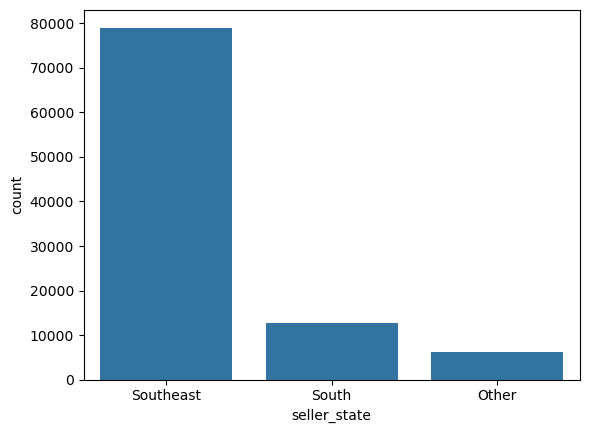

In [65]:
sns.countplot(
    data = data,
    x = "seller_state"
)

### Distribución variables continuas

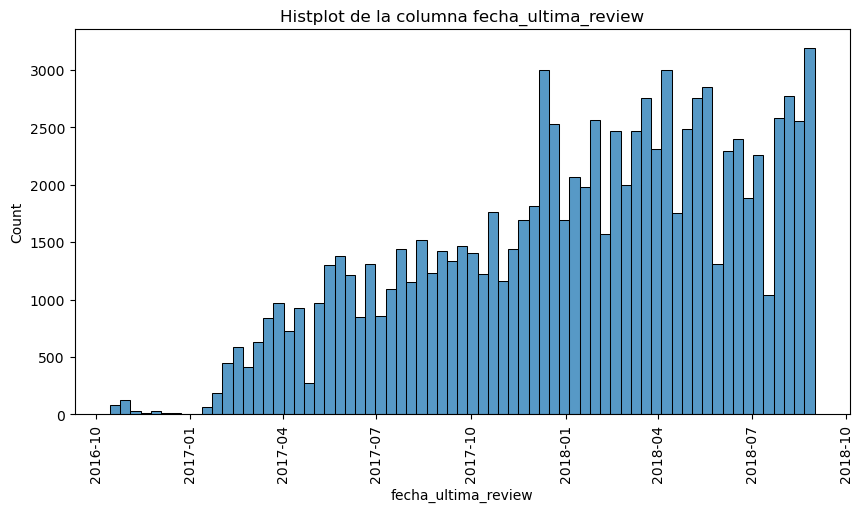

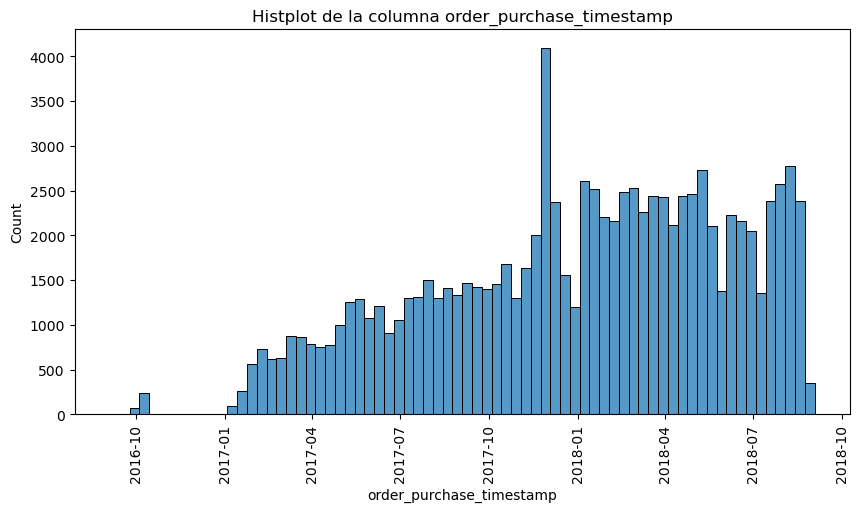

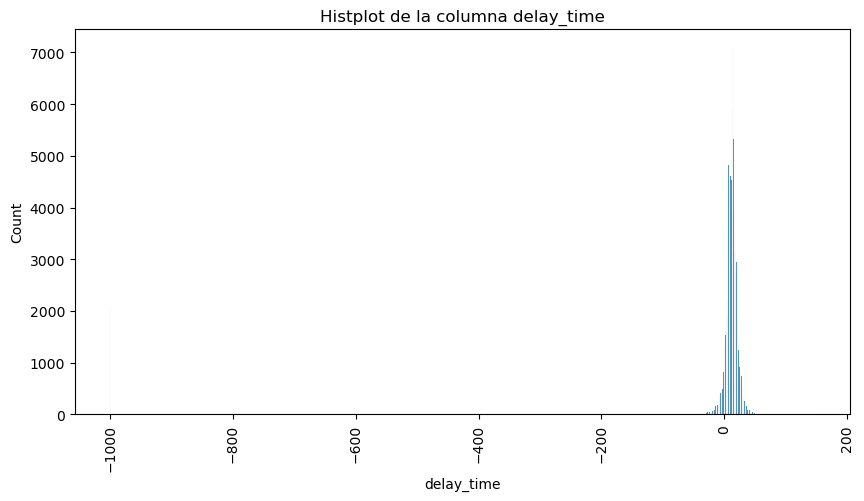

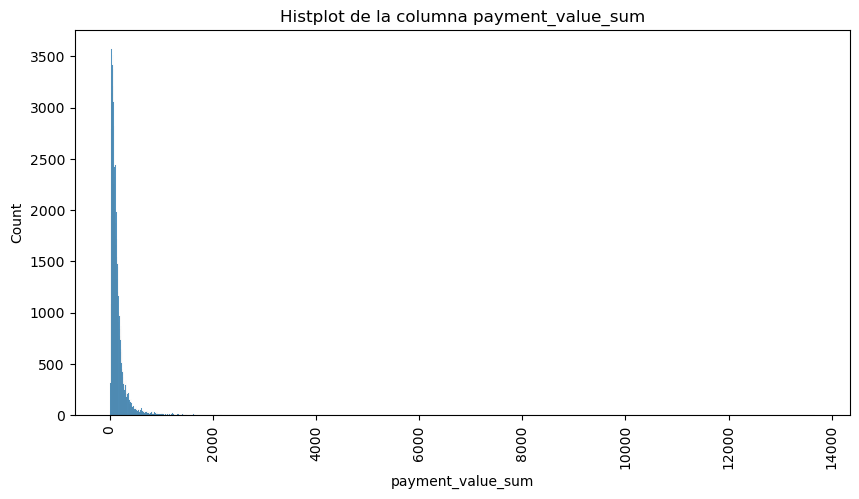

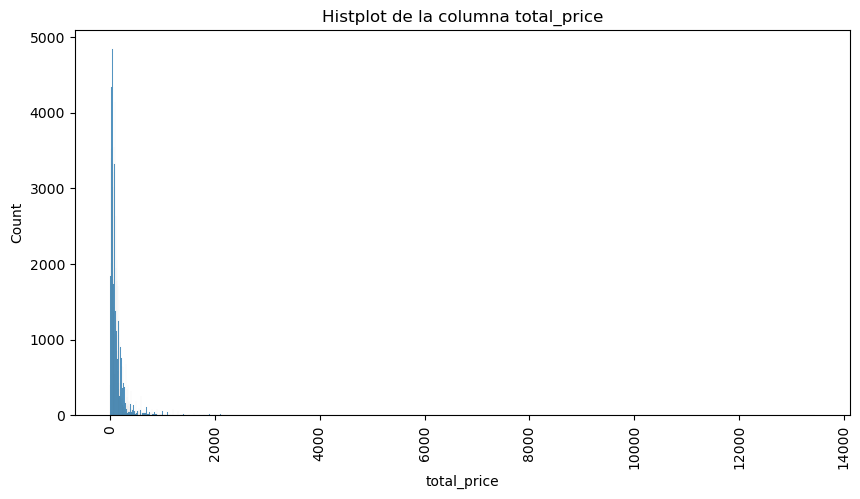

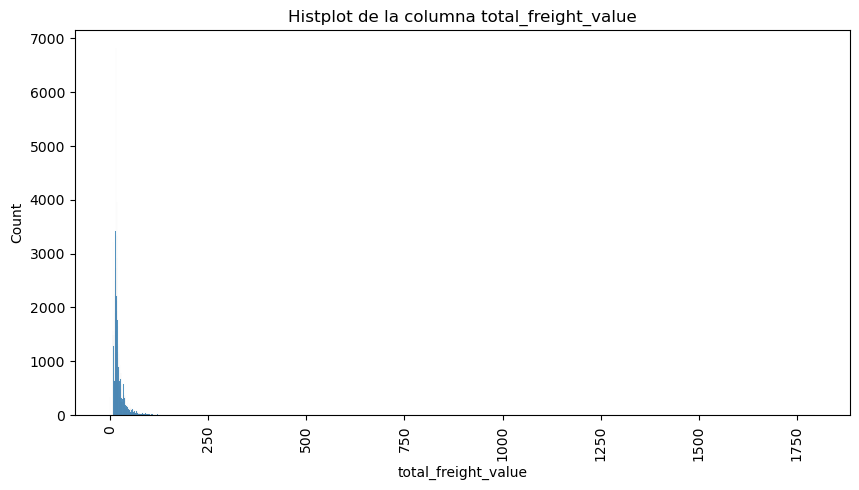

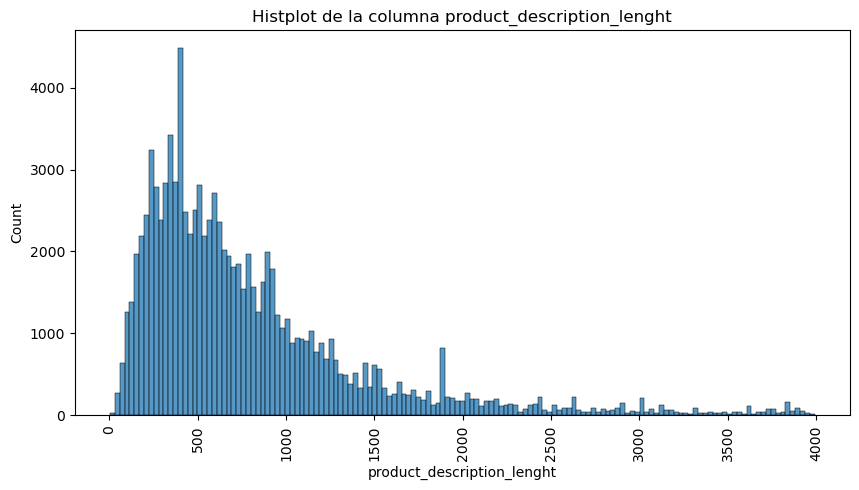

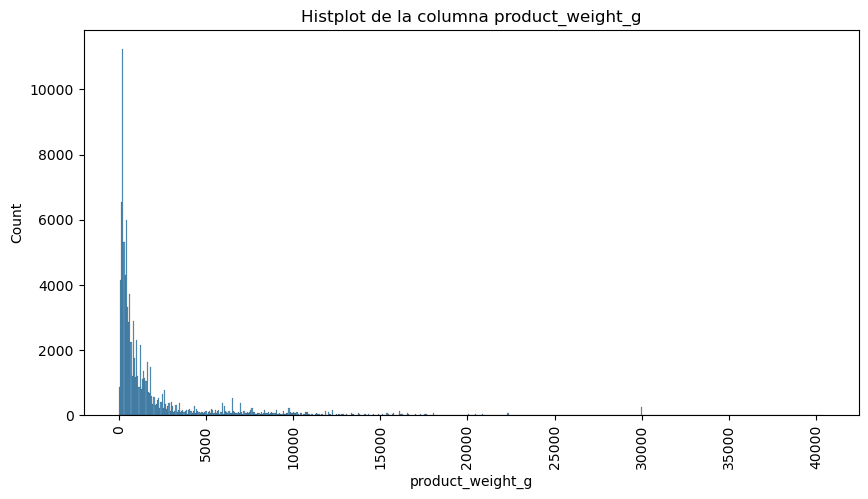

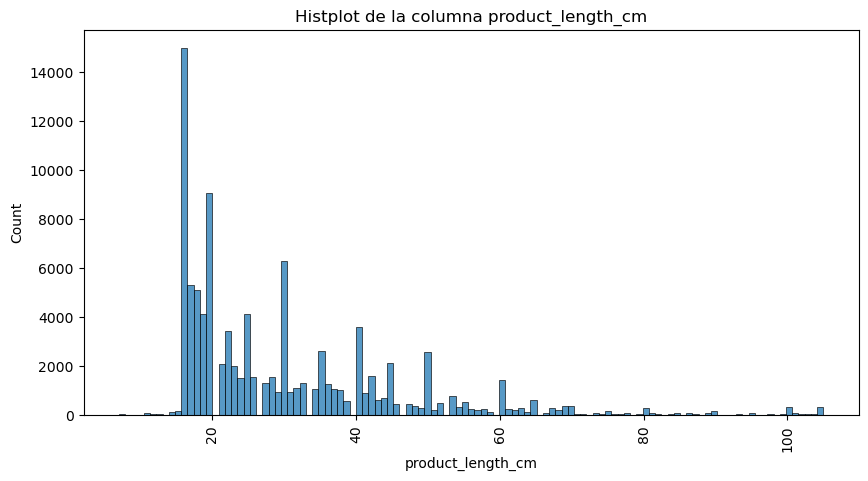

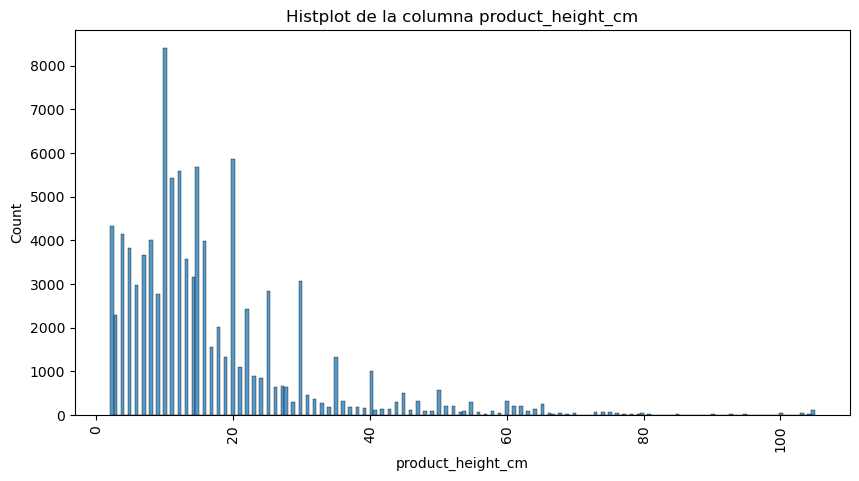

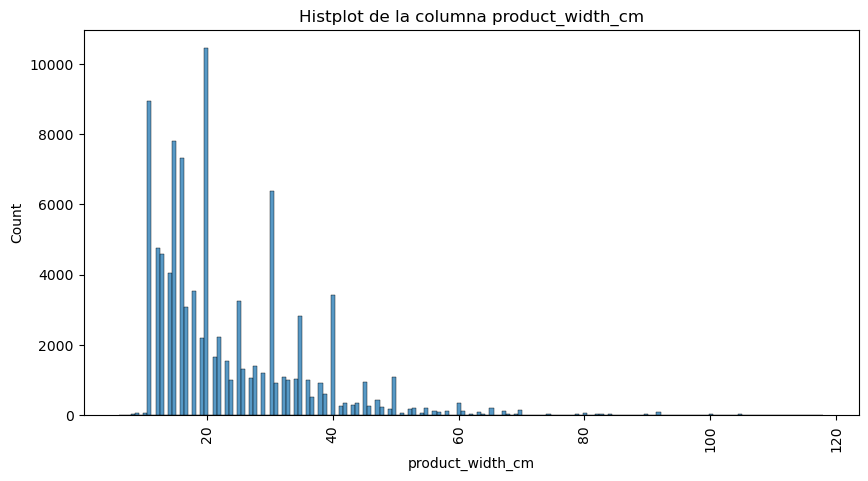

In [67]:
for columna in data[[
    "fecha_ultima_review",
    "order_purchase_timestamp",
    "delay_time",
    "payment_value_sum",
    "total_price",
    "total_freight_value",
    "product_description_lenght",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
]]:
    plt.figure(figsize = (10,5))
    sns.histplot(data = data, x = columna)
    plt.title(f"Histplot de la columna {columna}")
    plt.xticks(rotation = 90)
    plt.show() 

#### Fecha_review

<Axes: xlabel='fecha_ultima_review', ylabel='Count'>

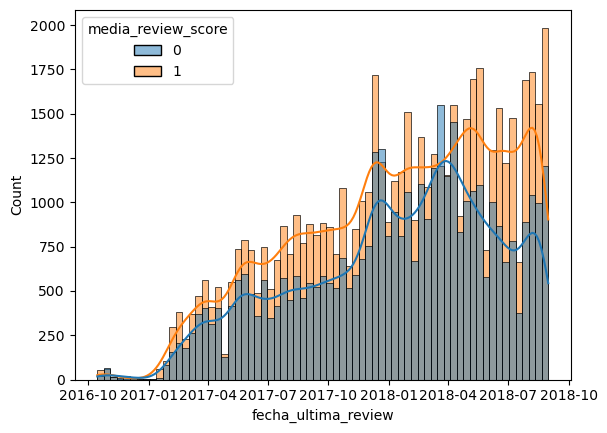

In [69]:
# analizar distribución cntra reseñas
sns.histplot(
    data = data,
    x = "fecha_ultima_review",
    hue = "media_review_score",
    kde = True
)

In [70]:
# el dato de fecha de la review puede ser mas interesante en comparacion con fecha de compra
# se transforma fecha_review en review_delay
data = data.assign(
    review_delay = (data["fecha_ultima_review"] - data["order_purchase_timestamp"]).dt.days.astype("Int64")
)

In [71]:
data = data.drop(columns = "fecha_ultima_review")

In [72]:
data.review_delay.min()

-40

In [73]:
data.loc[data.review_delay < 0, :].size

110

In [74]:
# se eliminan las filas con review_delay < 0
data = data.loc[data["review_delay"] >= 0, :]

<Axes: xlabel='review_delay', ylabel='count'>

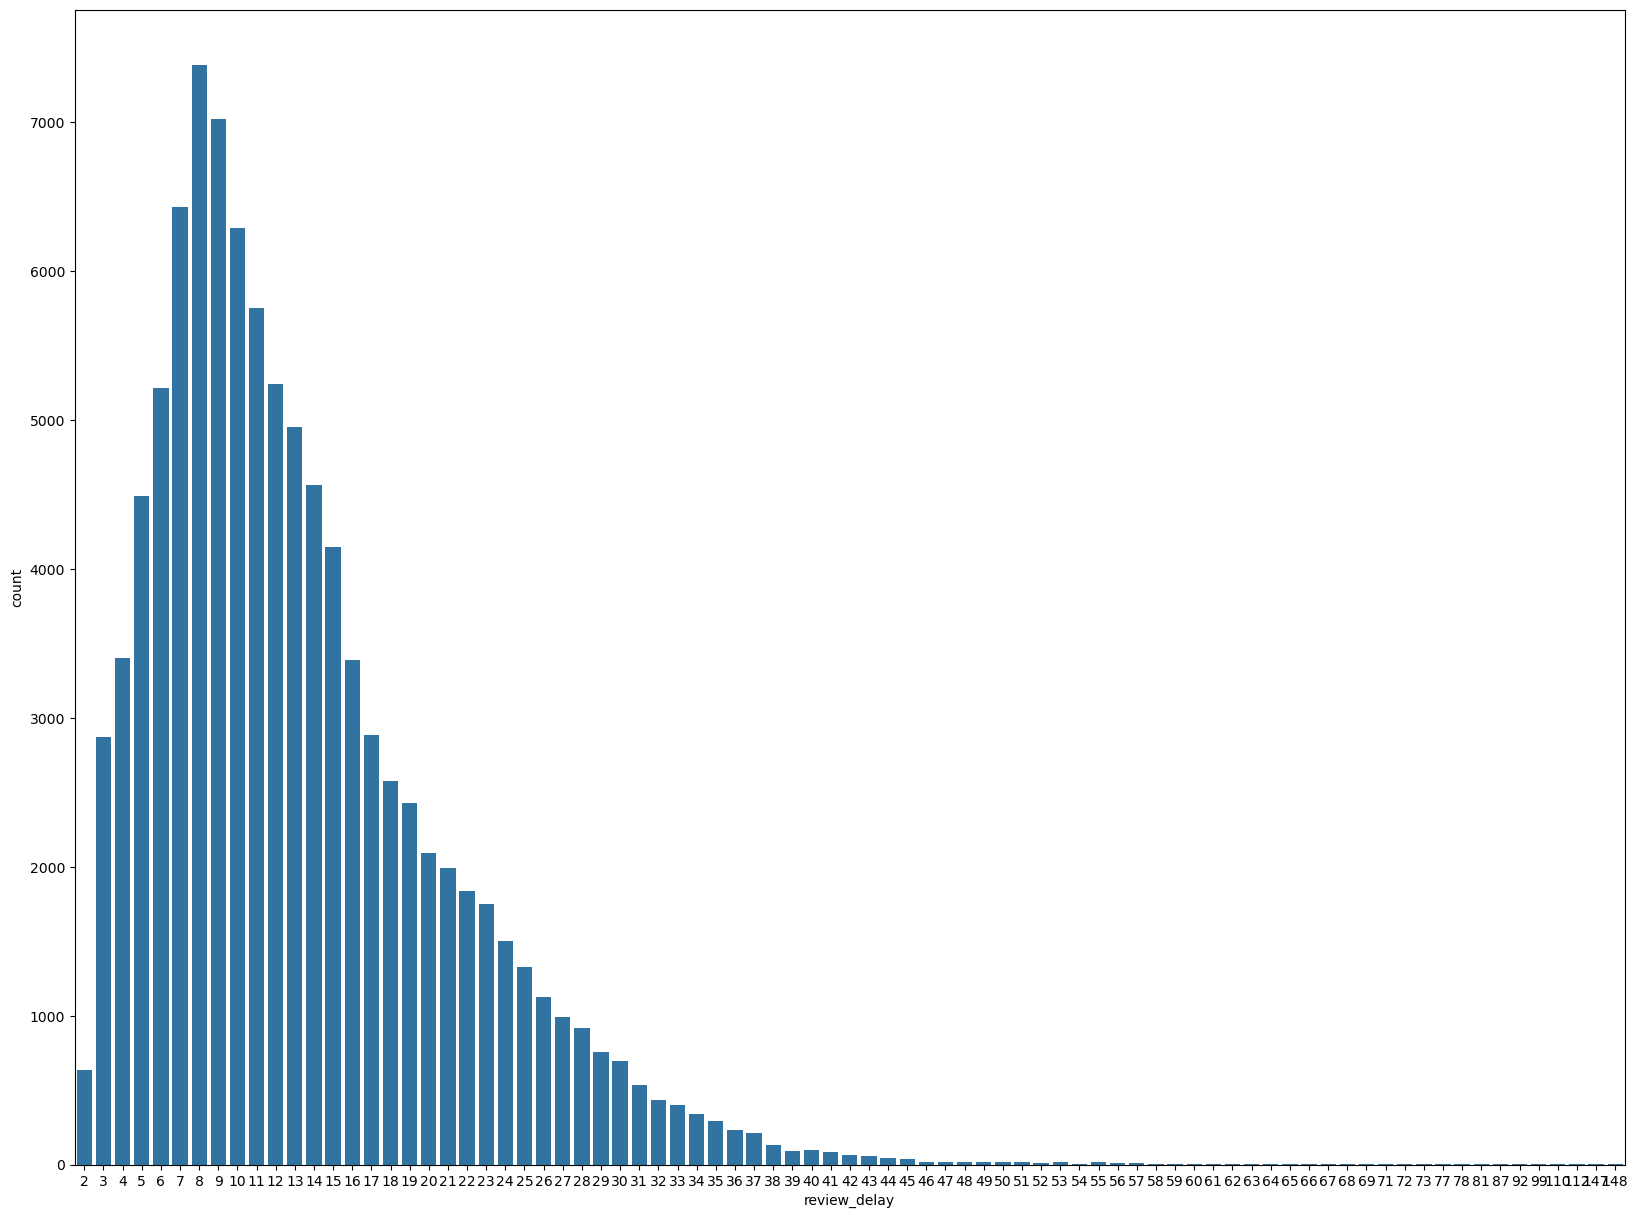

In [75]:
plt.figure(figsize = (20, 15))

sns.countplot(
    data = data,
    x = "review_delay"
)

#### Fecha_compra

<Axes: xlabel='order_purchase_timestamp', ylabel='Count'>

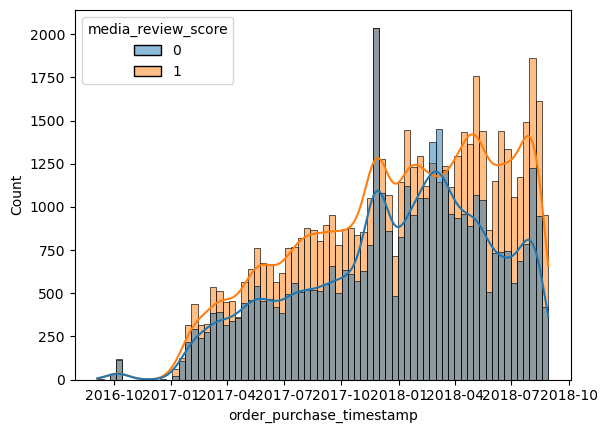

In [77]:
# analizar distribución contra reseñas
sns.histplot(
    data = data,
    x = "order_purchase_timestamp",
    hue = "media_review_score",
    kde = True
)

In [78]:
# agrupar por temporada
data["order_purchase_timestamp"] = np.where(
    data["order_purchase_timestamp"].dt.month.isin([3,4,5]),
    "Otoño",
    np.where(
        data["order_purchase_timestamp"].dt.month.isin([6,7,8]),
        "Invierno",
        np.where(
            data["order_purchase_timestamp"].dt.month.isin([6,10,11]),
            "Primavera",
            "Verano"
        )
    )
)

<Axes: xlabel='order_purchase_timestamp', ylabel='count'>

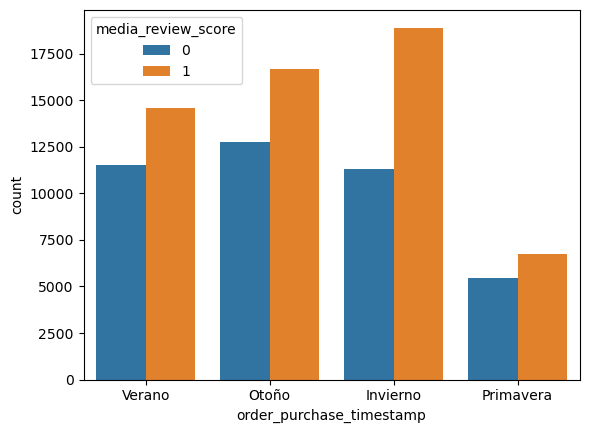

In [79]:
sns.countplot(
    data = data,
    x = "order_purchase_timestamp",
    hue = "media_review_score"
)

#### Delay_time

In [81]:
# averiguar cuantas filas tienen valor -1000
# --> se habia asignado a las variables que tenían nulls
data.loc[data["delay_time"] == -1000, :].shape[0] / data.shape[0]

0.021294849404050617

<Axes: xlabel='delay_time', ylabel='Count'>

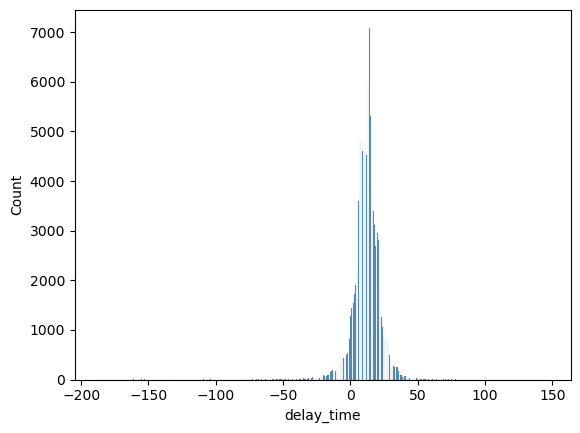

In [82]:
sns.histplot(
    data = data[data["delay_time"] != -1000],
    x = "delay_time"
)

In [83]:
# se eliminan filas con delay_time = -1000 (2% de los datos)
data = data[data["delay_time"] != -1000]

#### Payment_value, Total_price, Freight_value

Estas variables presentan una distribución centrada al rededor dee un valor y luego unas colas largas debida a la presencia de outliers. 

Los outliers no afectan demasiado a un modelo de arboles, pero para mejor eficiencia del modelo es mejor hacer una transformación a valores logaritmicos.

In [86]:
# se introducen columnas con valores transformados en log
data = data.assign(
    payment_value_log = lambda x: np.log1p(x['payment_value_sum']),
    total_price_log = lambda x: np.log1p(x['total_price']),
    total_freight_value_log = lambda x: np.log1p(x['total_freight_value'])
)

In [87]:
# se eliminan columnas originales
data = data.drop(columns = ["payment_value_sum", "total_price", "total_freight_value"])

#### Description_length

<Axes: xlabel='product_description_lenght', ylabel='Count'>

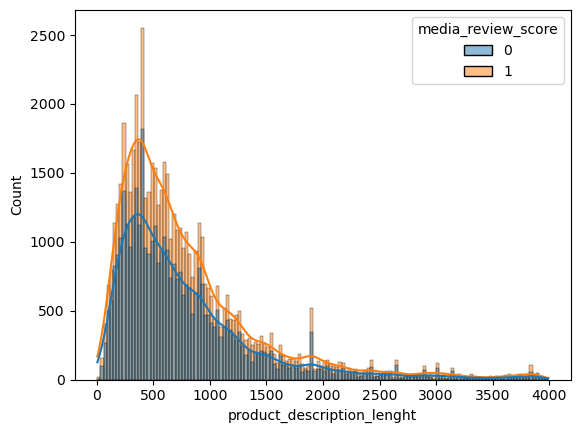

In [89]:
sns.histplot(
    data = data,
    x = "product_description_lenght",
    hue = "media_review_score",
    kde = True
)

# se deja tal cual

#### Product_weight, Product_length, Product_height, Product_width

Estas variables se pueden condensar en una variable de densidad del bulto.

In [92]:
#data.assign(
#    product_density = data["product_weight_g"] / (data["product_length_cm"] * data["product_height_cm"] * data["product_width_cm"])
#)

## Analisis data transformada

In [94]:
data.columns

Index(['order_id', 'media_review_score', 'order_purchase_timestamp',
       'delay_time', 'customer_state', 'payment_type', 'number_items',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'seller_state', 'seller_topN',
       'product_topN', 'repeat_customer', 'review_delay', 'payment_value_log',
       'total_price_log', 'total_freight_value_log'],
      dtype='object')

In [95]:
data = data.drop(columns = "order_id")

In [96]:
data.dtypes

media_review_score                 int64
order_purchase_timestamp          object
delay_time                         int64
customer_state                    object
payment_type                      object
number_items                      object
product_description_lenght       float64
product_photos_qty                object
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
product_category_name_english     object
seller_state                      object
seller_topN                        int64
product_topN                       int64
repeat_customer                    int64
review_delay                       Int64
payment_value_log                float64
total_price_log                  float64
total_freight_value_log          float64
dtype: object

### Alnalisis correlación entre variables numericas

In [98]:
data["delay_time"].dtypes

dtype('int64')

In [99]:
col_num = []

for i in data.columns:
    dtype = data[i].dtypes
    if ('int' in str(dtype)) or ('float' in str(dtype)):
        col_num.append(i)
col_num

['media_review_score',
 'delay_time',
 'product_description_lenght',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'seller_topN',
 'product_topN',
 'repeat_customer',
 'payment_value_log',
 'total_price_log',
 'total_freight_value_log']

In [100]:
data_num = data.loc[:, col_num]
data_num

,media_review_score,delay_time,product_description_lenght,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_topN,product_topN,repeat_customer,payment_value_log,total_price_log,total_freight_value_log
0,1,9,598.0,650.0,28.0,9.0,14.0,1,1,0,4.293059,4.092677,2.659560
1,0,3,239.0,30000.0,50.0,30.0,40.0,1,0,0,5.563869,5.484382,3.041184
2,1,14,695.0,3050.0,33.0,13.0,33.0,0,1,0,5.383899,5.298317,2.937573
3,0,6,480.0,200.0,16.0,10.0,15.0,0,0,0,3.287655,2.638343,2.623944
4,1,16,409.0,3750.0,35.0,40.0,30.0,0,1,0,5.389254,5.302807,2.951780
...,...,...,...,...,...,...,...,...,...,...,...,...,...
97911,1,8,1002.0,10150.0,89.0,15.0,40.0,1,1,0,5.841804,5.707077,3.793465
97912,1,9,232.0,8950.0,45.0,26.0,38.0,0,1,0,5.959793,5.860786,3.625141
97913,1,13,869.0,967.0,21.0,24.0,19.0,1,1,0,4.769413,4.614130,2.887590
97914,1,9,1306.0,100.0,20.0,20.0,20.0,1,1,0,4.185251,4.042876,2.274186


<Axes: >

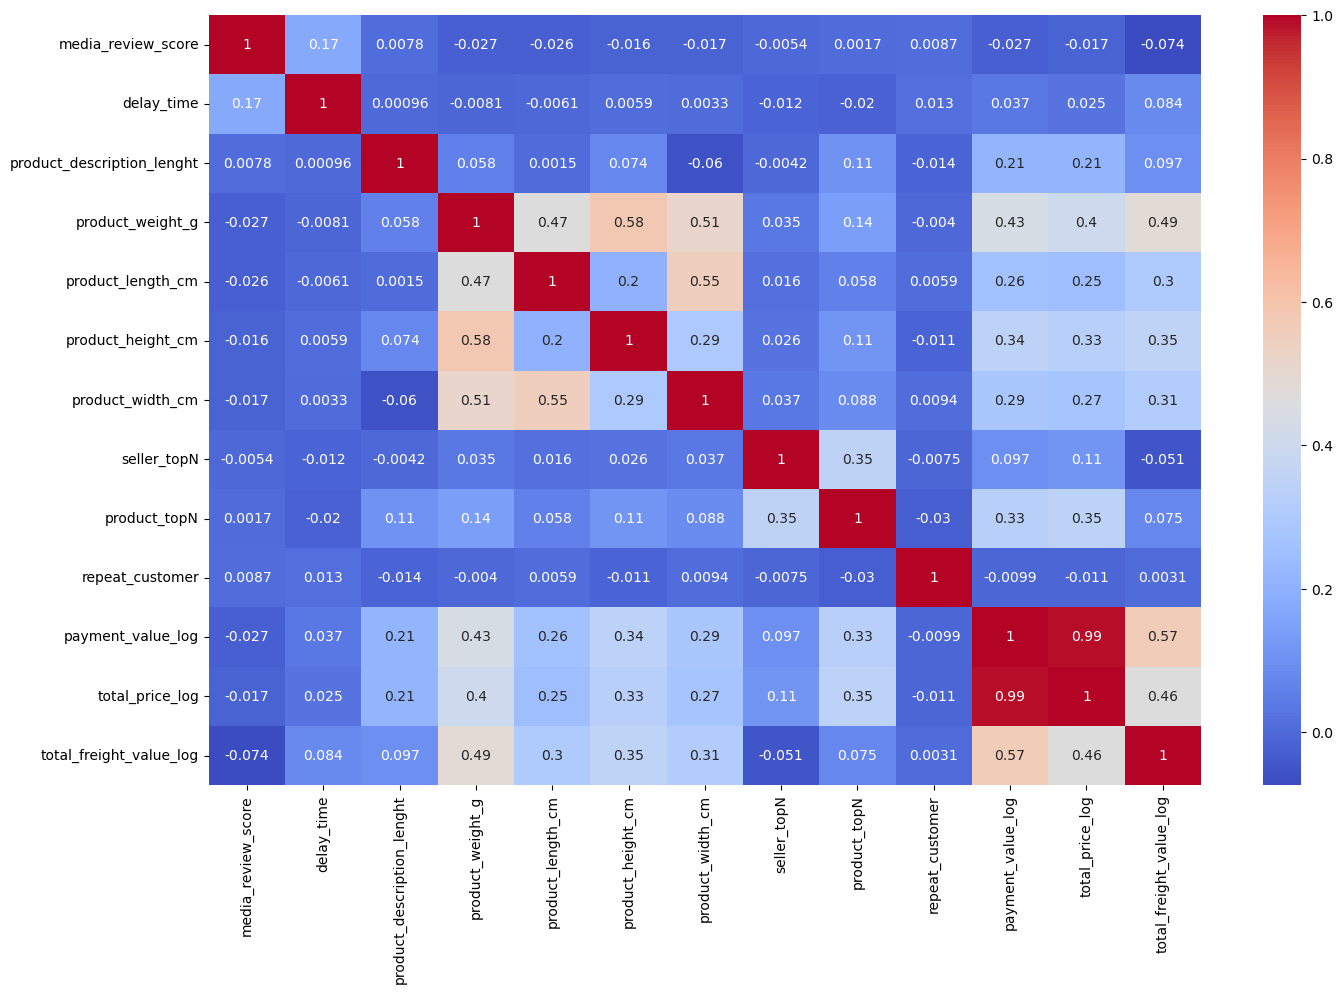

In [101]:
matriz_correlacion = data_num.corr()
plt.figure(figsize = (16,10))
sns.heatmap(matriz_correlacion, cmap = "coolwarm", annot = True)

In [102]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

n_columnas = data_num.shape[1]

for i in range(1, n_columnas):
    VIF = variance_inflation_factor(data_num, i)
    columna = data_num.columns[i]
    print(f"{columna}: {VIF}")

delay_time: 2.49898380555451
product_description_lenght: 2.6500129179945753
product_weight_g: 2.6231982318799862
product_length_cm: 6.984085858887827
product_height_cm: 3.9629500955646266
product_width_cm: 8.000490018815452
seller_topN: 3.9585334547491944
product_topN: 3.240487214275135
repeat_customer: 1.0349627923471778
payment_value_log: 2180.0024888837247
total_price_log: 1455.8615347274676
total_freight_value_log: 107.31805706279057


In [103]:
data_num = data.loc[:, col_num]
data_num = data_num.drop(columns = ["total_price_log", "total_freight_value_log"])

n_columnas = data_num.shape[1]

for i in range(1, n_columnas):
    VIF = variance_inflation_factor(data_num, i)
    columna = data_num.columns[i]
    print(f"{columna}: {VIF}")

delay_time: 2.4517101967807062
product_description_lenght: 2.6499111724431126
product_weight_g: 2.4219684885997497
product_length_cm: 6.897048778640872
product_height_cm: 3.9362115969631795
product_width_cm: 7.947828673425618
seller_topN: 3.885717569672151
product_topN: 3.114707743124315
repeat_customer: 1.0345683374526056
payment_value_log: 15.874854701087795


In [104]:
# condensamos variables de dimensiones del bulto en variable densidad
data_num = data.loc[:, col_num]
data_num = data_num.drop(columns = ["total_price_log", "total_freight_value_log"])
data_num = data_num.assign(
    product_density = data_num["product_weight_g"] / (data_num["product_length_cm"] * data_num["product_height_cm"] * data_num["product_width_cm"])
)

data_num = data_num.drop(columns = [ "product_weight_g", "product_height_cm", "product_length_cm", "product_width_cm"])

In [105]:
n_columnas = data_num.shape[1]

for i in range(1, n_columnas):
    VIF = variance_inflation_factor(data_num, i)
    columna = data_num.columns[i]
    print(f"{columna}: {VIF}")

delay_time: 2.4412874757035223
product_description_lenght: 2.6049721691307135
seller_topN: 3.8482320022132326
product_topN: 3.090990742603904
repeat_customer: 1.0340163618563938
payment_value_log: 8.172900300757854
product_density: 1.0746389255588487


ATENCION: CONSIDERAR HACER ESTOS CAMBIOS EN TABLA FINAL!

In [107]:
data = data.drop(columns = ["total_price_log", "total_freight_value_log"])
data = data.assign(
    product_density = data["product_weight_g"] / (data["product_length_cm"] * data["product_height_cm"] * data["product_width_cm"])
)

data = data.drop(columns = [ "product_weight_g", "product_height_cm", "product_length_cm", "product_width_cm"])

### Preparación columnas dummies

In [109]:
data.dtypes

media_review_score                 int64
order_purchase_timestamp          object
delay_time                         int64
customer_state                    object
payment_type                      object
number_items                      object
product_description_lenght       float64
product_photos_qty                object
product_category_name_english     object
seller_state                      object
seller_topN                        int64
product_topN                       int64
repeat_customer                    int64
review_delay                       Int64
payment_value_log                float64
product_density                  float64
dtype: object

In [110]:
col_cat = []

for i in data.columns:
    dtype = data[i].dtypes
    if i != "media_review_score":
        if 'object' in str(dtype):
            col_cat.append(i)
col_cat

['order_purchase_timestamp',
 'customer_state',
 'payment_type',
 'number_items',
 'product_photos_qty',
 'product_category_name_english',
 'seller_state']

In [111]:
data = pd.get_dummies(
    data, 
    columns = col_cat, 
    drop_first=True
)

data.shape

(95826, 31)

In [112]:
data.columns

Index(['media_review_score', 'delay_time', 'product_description_lenght',
       'seller_topN', 'product_topN', 'repeat_customer', 'review_delay',
       'payment_value_log', 'product_density',
       'order_purchase_timestamp_Otoño', 'order_purchase_timestamp_Primavera',
       'order_purchase_timestamp_Verano', 'customer_state_Other',
       'customer_state_South', 'customer_state_Southeast',
       'payment_type_boleto', 'payment_type_credit_card', 'number_items_2.0',
       'number_items_Más de 2', 'product_photos_qty_2.0',
       'product_photos_qty_3.0', 'product_photos_qty_4.0',
       'product_photos_qty_5.0', 'product_photos_qty_Más de 5',
       'product_category_name_english_Fashion and Personal Care',
       'product_category_name_english_Home and Decoration',
       'product_category_name_english_Leisure, Toys and Arts',
       'product_category_name_english_Miscellaneous and Other Items',
       'product_category_name_english_Tools and Construction',
       'seller_state_S

## Generar modelo

### Dividir datos en training y testing

In [115]:
X = data.drop(columns = "media_review_score")
y = data["media_review_score"]

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    train_size = 0.75,
    test_size=0.25
)

### Buscar mejor depth_level

In [118]:
for i in np.arange(1, 50, 5):
    modelo = DecisionTreeClassifier(max_depth = i)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{i} -> {np.round(acc,4)}")

1 -> 0.63
6 -> 0.6384
11 -> 0.637
16 -> 0.62
21 -> 0.5972
26 -> 0.579
31 -> 0.5648
36 -> 0.5609
41 -> 0.56
46 -> 0.5596


In [119]:
for i in np.arange(1, 11):
    modelo = DecisionTreeClassifier(max_depth = i)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{i} -> {np.round(acc,4)}")

1 -> 0.63
2 -> 0.63
3 -> 0.6351
4 -> 0.638
5 -> 0.6388
6 -> 0.6384
7 -> 0.6381
8 -> 0.6379
9 -> 0.6376
10 -> 0.6384


### Seleccion del mejor modelo y construcción arbol

In [259]:
# mejor resultado: con 4
# muy parecido al resultado con 3 --> se elije 3 por mayor simplicidad
modelo = DecisionTreeClassifier(max_depth = 3)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
accuracy_score(y_test, y_pred)

0.6387694619526652

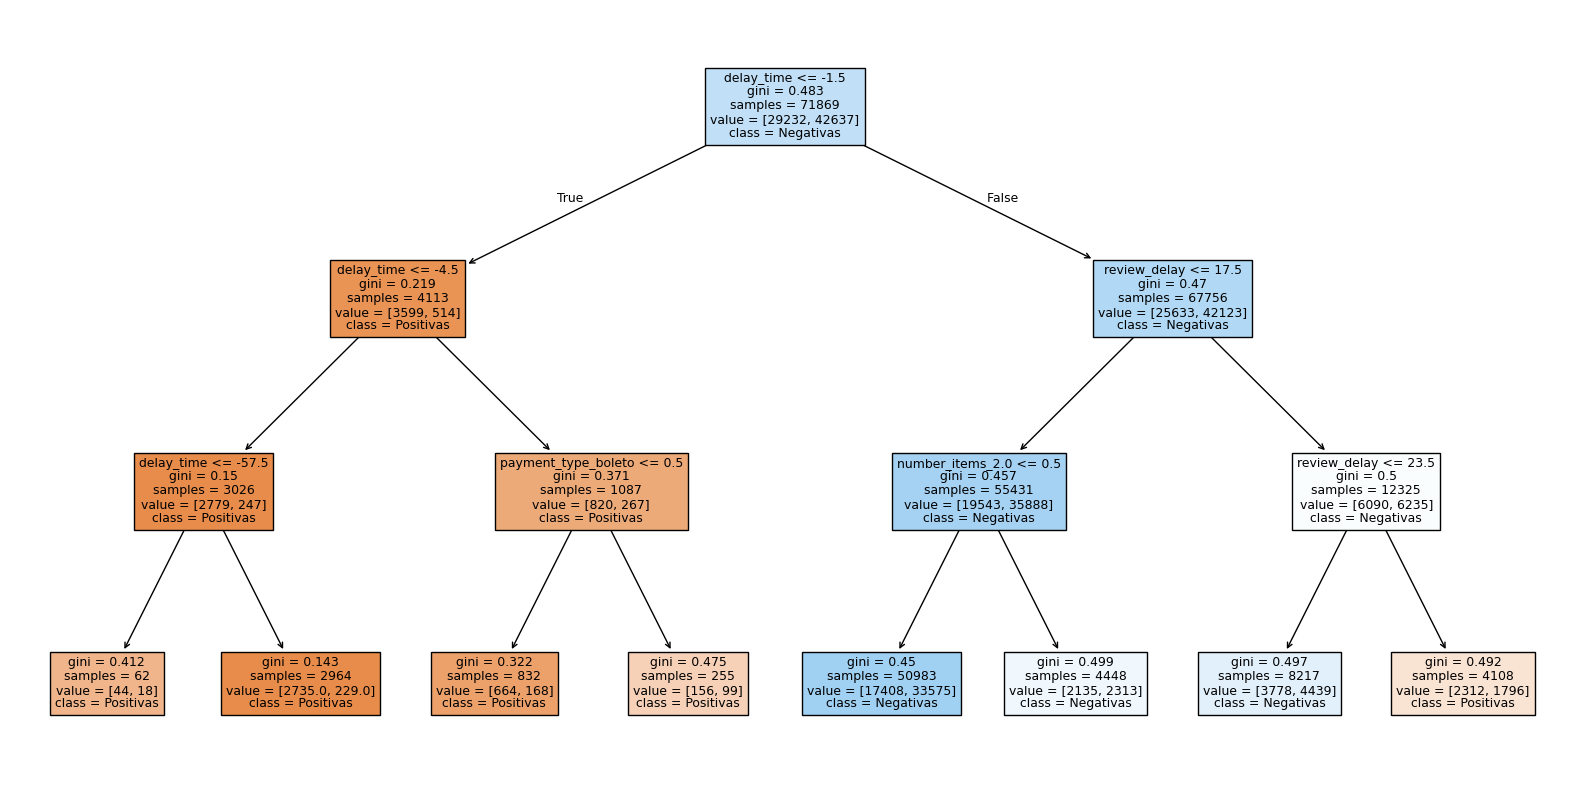

In [122]:
plt.figure(figsize=(20,10))
tree.plot_tree(modelo, filled = True, feature_names = X.columns, class_names = ["Positivas", "Negativas"])
plt.show()

## Validar modelo

In [124]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

In [261]:
matriz_confusion = confusion_matrix(y_test, y_pred)

In [263]:
TN = matriz_confusion[0][0]
TP = matriz_confusion[1][1]
FN = matriz_confusion[1][0]
FP = matriz_confusion[0][1]

In [265]:
## Accuracy
(TN + TP) / (TN + TP + FN + FP)

0.6387694619526652

In [267]:
## sensibilidad: me dice que porcentaje acerté de la gente que ha puesto buenas reseñas 
TP / (TP + FN)

0.8975179574710191

In [269]:
## especificidad: me dice que tan bueno es el modelo en acertar la gente que ha puesto malas reseñas
TN / (TN + FP)

0.27111964430072755

# Random Forest

In [240]:
for i in np.arange(1, 50, 5):
    modelo = RandomForestClassifier(max_depth = i)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{i} -> {np.round(acc,4)}")

1 -> 0.6213
6 -> 0.6374
11 -> 0.6424
16 -> 0.6408
21 -> 0.6378
26 -> 0.6313
31 -> 0.6276
36 -> 0.6217
41 -> 0.6212
46 -> 0.6224


In [243]:
for i in np.arange(6, 16):
    modelo = RandomForestClassifier(max_depth = i)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{i} -> {np.round(acc,4)}")

6 -> 0.6387
7 -> 0.6399
8 -> 0.6412
9 -> 0.6431
10 -> 0.6424
11 -> 0.6427
12 -> 0.642
13 -> 0.6423
14 -> 0.642
15 -> 0.6414


In [246]:
clf = RandomForestClassifier(max_depth=9)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [249]:
matriz_confusion = confusion_matrix(y_test, y_pred)

In [251]:
TN = matriz_confusion[0][0]
TP = matriz_confusion[1][1]
FN = matriz_confusion[1][0]
FP = matriz_confusion[0][1]

In [253]:
## Accuracy
(TN + TP) / (TN + TP + FN + FP)

0.6420252953207831

In [255]:
## sensibilidad: me dice que porcentaje acerté de la gente que ha puesto buenas reseñas 
TP / (TP + FN)

0.9327217125382263

In [257]:
## especificidad: me dice que tan bueno es el modelo en acertar la gente que ha puesto malas reseñas
TN / (TN + FP)

0.22898140662894098

# Xgboost

In [132]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

In [133]:
modelo_xgb = XGBClassifier(
    max_depth=11, 
    use_label_encoder=False, 
    eval_metric='mlogloss' # Se recomienda especificar la métrica
)

modelo_xgb.fit(X_train, y_train)

y_pred_xgb = modelo_xgb.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy de XGBoost: {accuracy_xgb}")

/opt/anaconda3/envs/entorno_python/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [17:13:02] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1765326940857/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy de XGBoost: 0.6133489168092833


In [134]:
matriz_confusion = confusion_matrix(y_test, y_pred_xgb)

In [135]:
TN = matriz_confusion[0][0]
TP = matriz_confusion[1][1]
FN = matriz_confusion[1][0]
FP = matriz_confusion[0][1]

In [136]:
## sensibilidad: me dice que porcentaje acerté de la gente que ha puesto buenas reseñas 
TP / (TP + FN)

0.7805277007325225

In [137]:
## especificidad: me dice que tan bueno es el modelo en acertar la gente que ha puesto malas reseñas
TN / (TN + FP)

0.37580840743734845